## Interpretability in a neural network

In [14]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask
import torch 
import torch.nn.functional as F
import torchvision.transforms.functional as TF


## Instructions

Choose a pretrained model - DONE

Choose 3 classes present in the pre-trained weights of your chosen model - DONE

1. 


For each class produce an attribution map for an image containing a positive example and a negative example.

Describe what you are seeing, what does the attribution maps show in each case? Analyze logits for similar activations for at least one example.


AND


At least 2 positive examples (images) - Look at several layers. Analyze the differences between early, middle and late layers. 

1 example of an image containing a class NOT present in the pre-trained model and analyse the result.



## Loading model and pretrained weights

In [15]:
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

# PART I: feature attribution

## Creating a function to create the Class Attribution Maps

In [ ]:
# preparing the CAM-extractor once
target_layer = model.layer4[-1] #counts as the "default layer" in practice, it's the last conv before pooling layer
cam_extractor = LayerCAM(model, target_layer=target_layer) # CAM-hooks are in the model, will register everything

def generate_cam(img_path, class_name, return_logits=False):
    # load and preprocess pic
    preprocess = weights.transforms() # same normalization and scaling that the model was trained with
    img = decode_image(img_path)
    input_tensor = preprocess(img).unsqueeze(0) # preprocessing and adding batch dimension to image -> (1, C, H, W)

    # forward pass
    out =  model(input_tensor) # here are the logits for all classes
    logits = out.squeeze(0)

    # find class index from class 
    class_idx = weights.meta["categories"].index(class_name)
        
    # get CAM
    activation_map = cam_extractor(class_idx, out)[0]

    # scale up CAM to pic size
    H, W = img.shape[-2:]

    cam = F.interpolate(
        activation_map.unsqueeze(0).unsqueeze(0),   # (1,1,7,7)
        size=(H, W),  # (H, W) = (819, 1024)
        mode="bicubic",
        align_corners=False
    ).squeeze()

    # normalize CAM
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # plot overlay
    plt.imshow(img.permute(1,2,0))
    plt.imshow(cam.cpu(), cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

    top5_vals, top5_idxs = torch.topk(logits,5)

    print("Top 5 classes:")
    for val, idx in zip(top5_vals, top5_idxs):
        print(f"{idx.item():4d}  {val.item():.4f}  {weights.meta['categories'][idx]}")

    if return_logits:
        return logits

## Choosing 3 classes

### class 1: chow chow

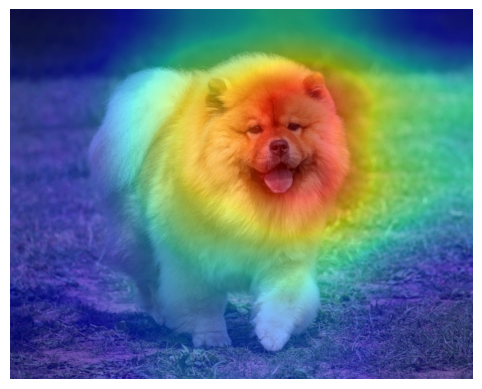

Top 5 classes:
 260  18.2434  chow
 259  13.7561  Pomeranian
 244  11.6529  Tibetan mastiff
 263  10.6850  Pembroke
 154  10.5107  Pekinese


tensor([ 1.9515e-01,  2.7360e-02, -1.5008e+00, -3.9430e+00, -1.4732e+00,
         2.4123e+00,  3.5694e-01,  6.2975e-01,  2.9875e+00, -8.0172e-01,
        -3.2148e-01, -3.2952e+00, -1.6142e+00, -2.5736e+00, -2.2578e+00,
        -3.5140e+00, -3.8030e+00, -1.0039e+00, -1.8791e+00, -2.2711e+00,
        -1.0131e+00, -1.9041e+00, -3.0348e+00,  3.6692e-01, -4.0025e-01,
         8.0236e-01,  5.3128e-03, -7.5559e-01,  2.2999e+00, -2.2357e+00,
         3.4271e-02, -9.8817e-02,  1.2110e+00,  6.4769e-01,  8.9229e-01,
         1.4292e+00,  7.8412e-01,  1.2453e-01, -9.4160e-01, -1.9034e+00,
        -5.4218e-01, -2.2608e+00, -1.6081e+00, -2.2416e+00,  1.9942e-01,
        -2.2415e+00, -2.0316e+00, -1.0995e+00, -4.4898e+00,  3.3119e+00,
         8.2613e-01,  1.0596e-01, -1.4638e+00, -1.6555e-01,  3.0586e-01,
        -8.4694e-01,  4.6546e-01, -1.2176e+00, -1.0318e+00, -1.8858e+00,
         2.2022e+00,  1.1952e+00,  1.5662e+00,  4.6994e-01, -1.9810e+00,
        -2.7347e-01,  5.1099e-01,  1.0666e+00, -7.5

In [17]:
# positive example
generate_cam("chow_chow.jpg", "chow", return_logits=True)

What does the class attribution map show? It shows what part of the picture contributes to the logit of the class.

We also chose to return the logits from the model. Not easy to find the highest values among the logits. For convenience we can refer to the printed list above containing the top 5 classes that the model activates. (You will find a similar list for every following CAM, but not the raw logits). These are the classes that the model find most probable for the image. We can make a CAM on the same pic for the class with the second highest logit. We want to compare to see if they activate the same regions. 

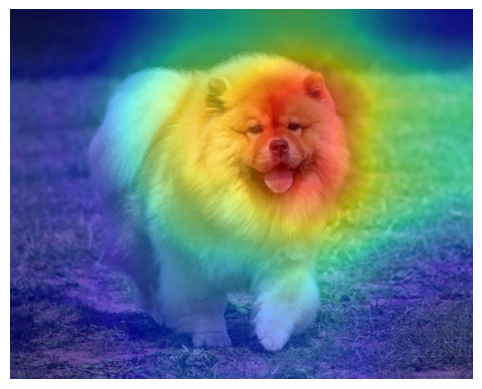

Top 5 classes:
 260  18.2434  chow
 259  13.7561  Pomeranian
 244  11.6529  Tibetan mastiff
 263  10.6850  Pembroke
 154  10.5107  Pekinese


In [23]:
generate_cam("chow_chow.jpg", "Pomeranian")

This CAM-map is very similar to the previous. It seems that the top 2 classes get high logits because of the same regions in the picture. This means that the model uses pretty much the same visual features to activate both classes, which explains why the logits are similar. 

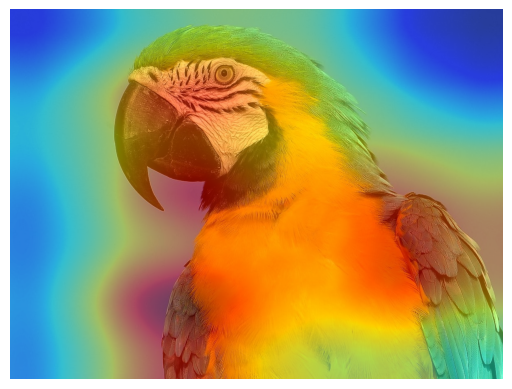

Top 5 classes:
  88  24.8937  macaw
  90  17.7060  lorikeet
  92  14.5843  bee eater
  96  12.8494  toucan
  87  11.6063  African grey


In [18]:
# negative example
generate_cam("bird.jpg", "chow")

Analyze 

The CAM is showing what parts of the pic supports the chosen class. CAM is trying to find something in the picture that is similar to chow chow features. We see spread out and irrelevant reagions. 

### class 2: rapeseed

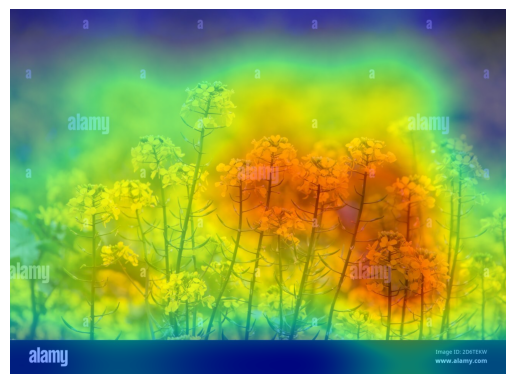

Top 5 classes:
 984  21.5339  rapeseed
 425  8.4546  barn
 888  7.3341  viaduct
 825  7.2183  stone wall
 982  6.9040  groom


In [19]:
# positive example
generate_cam("raps.jpg", "rapeseed")

analyze

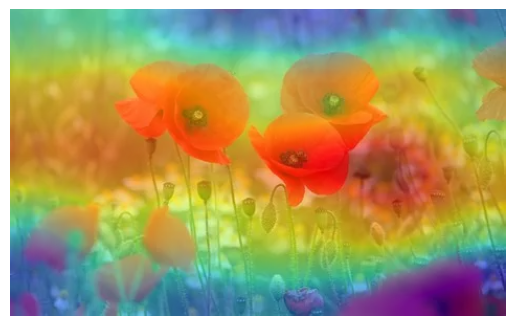

Top 5 classes:
 989  8.0253  hip
 865  7.8978  toyshop
 716  7.6868  picket fence
 325  7.3843  sulphur butterfly
 580  6.6415  greenhouse


In [20]:
#negative example
generate_cam("poppies.jpg", "rapeseed")

analyze

### class 3: lakeside 

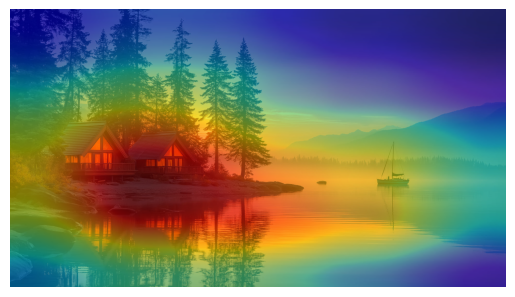

Top 5 classes:
 975  14.9229  lakeside
 449  12.2317  boathouse
 978  11.1306  seashore
 472  10.3442  canoe
 483  9.2781  castle


In [21]:
generate_cam("lakeside.jpg", "lakeside")

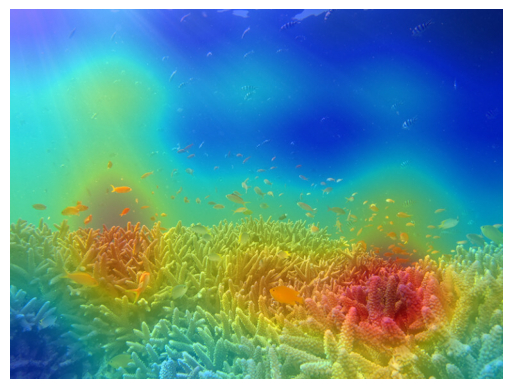

Top 5 classes:
 973  16.6371  coral reef
 393  12.8017  anemone fish
 108  11.1438  sea anemone
 327  10.4189  starfish
 983  10.0827  scuba diver


In [35]:
generate_cam("pictures/ocean.jpg", "lakeside")

### Interpretability



#### I. Feature attribution
with CAM

CAM visar var i bilden modellen tittar.

#### II. Feature visualization

Feature visualization med FEATURE MAPS från valda lager visar vad filtret föredrar som input.

Du skickar in en bild i modellen och plockar ut feature maps från ett visst lager. Sen visualiserar du som en gråskale-bild. 

# PART II: Feature visualization

Let's create a function to extact feature maps from a chosen layer. 

In [78]:
def visualize_feature_maps(model, layer, img_path, num_maps=8):
    preprocess = weights.transforms()
    img = decode_image(img_path) # pic as tensor (C, H, W)
    input_tensor = preprocess(img).unsqueeze(0) # normalizing and scaling to ImageNet-standards 
                                                #and adding batch-dimension --> (1, C, H, W)

    # hook function to capture feature maps - runs automatically at forward pass
    activations = {} # for storing feature maps
    def hook_fn(module, input, output):
        activations['maps'] = output.detach().cpu() # output=feature maps from the layer
                                    # detach from autograd (no training)
                                            # move to CPU for plotting

    handle = layer.register_forward_hook(hook_fn) # when the layer runs, hook_fn also runs

    _ = model(input_tensor) # model does forward pass, when it reaches chosen layer, feature maps are captured by the hook

    handle.remove()

    fmap = activations['maps'][0] 

    plt.figure(figsize=(12,6))
    for i in range(num_maps): # each feature map is a pic that shows what the layer reacts to
        plt.subplot(2, num_maps//2, i+1)
        plt.imshow(fmap[i], cmap='viridis')
        plt.axis('off')
    plt.show()

Before visualizing the feature maps from specific layers, let's see what layers the model actually has... What layers are the ones we want to viualize?

### First positive example - tabby cat

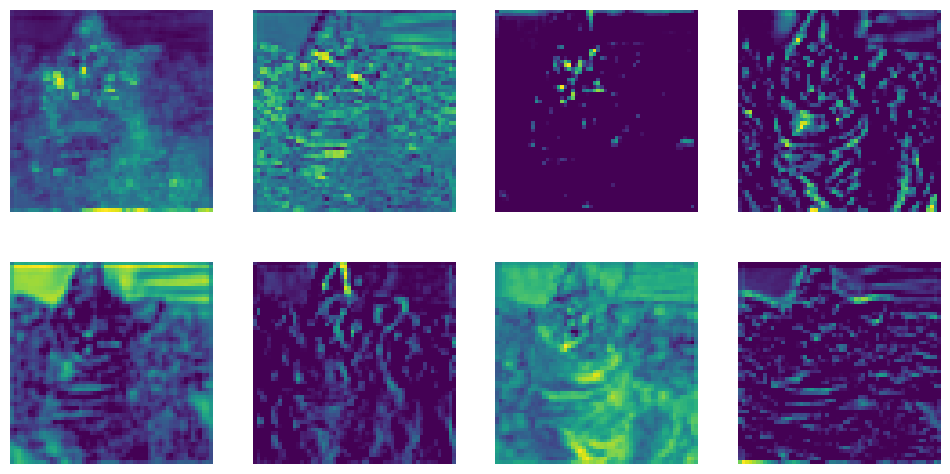

In [89]:
# feature maps from early layer
visualize_feature_maps(model, model.layer1[0], "pictures/tabby1.jpg")


The feature maps mostly still ressemble cats.
This layer reacted to edges; we see the outlines of the cat in almost all the maps. It also picks up on textures; we see the patterns of the fur in many of the maps.

In this layer, the model extracs low-level features. The different filtera are activated by different directions and patterns in the pictures, resulting in the varying texture-like activations.

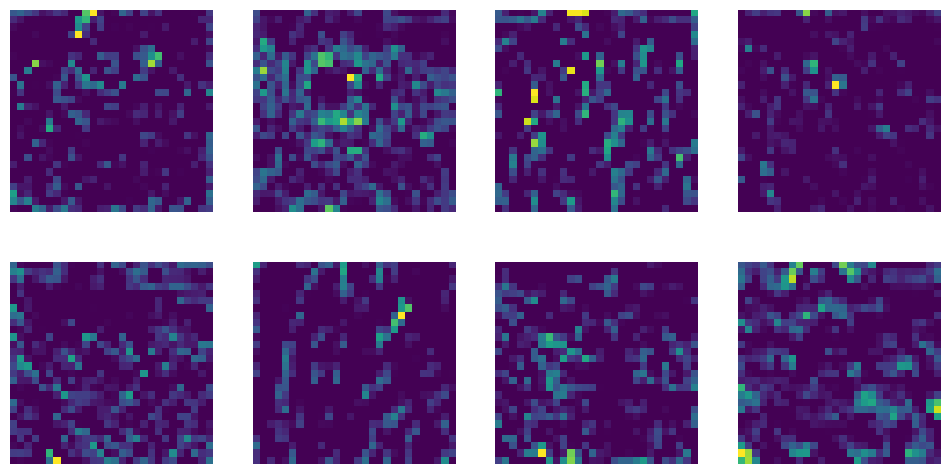

In [90]:
# middle layer
visualize_feature_maps(model, model.layer2[-1], "pictures/tabby1.jpg")


These maps no longer ressemble cats. It looks more abstract. 
There are much stronger contrasts, compared to the earlier layer's maps. 

The modell has started combining simple edges and textures into more structured patterns.

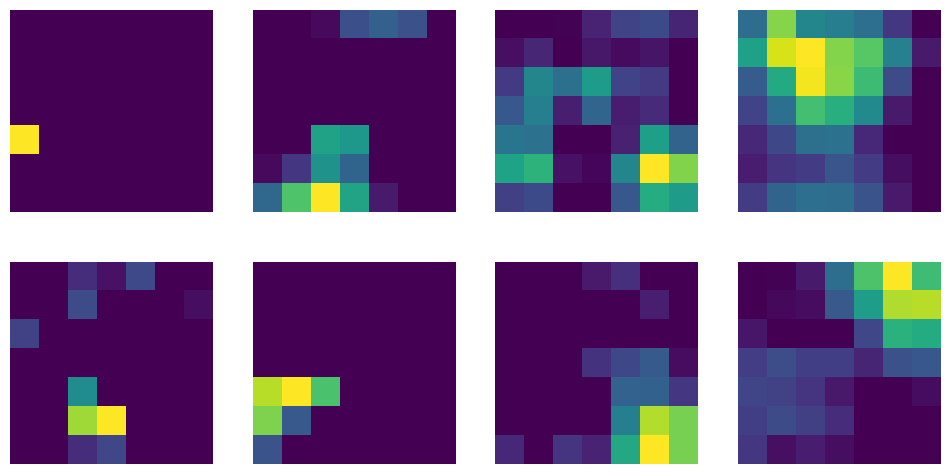

In [91]:
#late layer
visualize_feature_maps(model, model.layer4[-1], "pictures/tabby1.jpg")

In these feature maps for a late layer, we get much more abstract representations. There are fewer pixels, because they are lower dimensional.
We are now much further from the original picture compared to the early and middle layers.Now the feature maps show more like concentrated blobs.

The model in this layer has gone from recognising patterns in earlier layers, to recognizing concepts.
Here the layer reacts to semantic parts, i.e. parts of the cat that matters for the classification. This is why this the layer that you would use CAM on! This layer reacts to combinations patterns (it is using the output from the earlier layers!). 

### Second positive example - goldfish

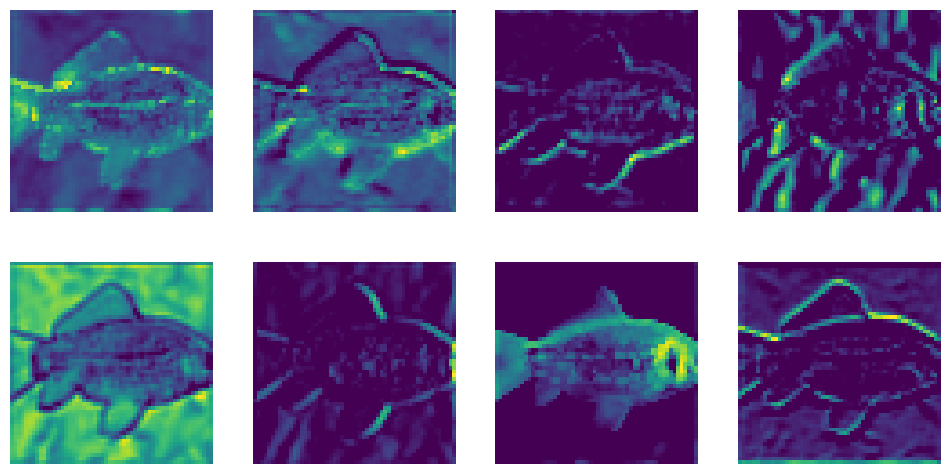

In [82]:
visualize_feature_maps(model, model.layer1[0], "pictures/gold.jpg")

Similarly to the earlier example, this early layer picks up on edges, contrasts and textures.

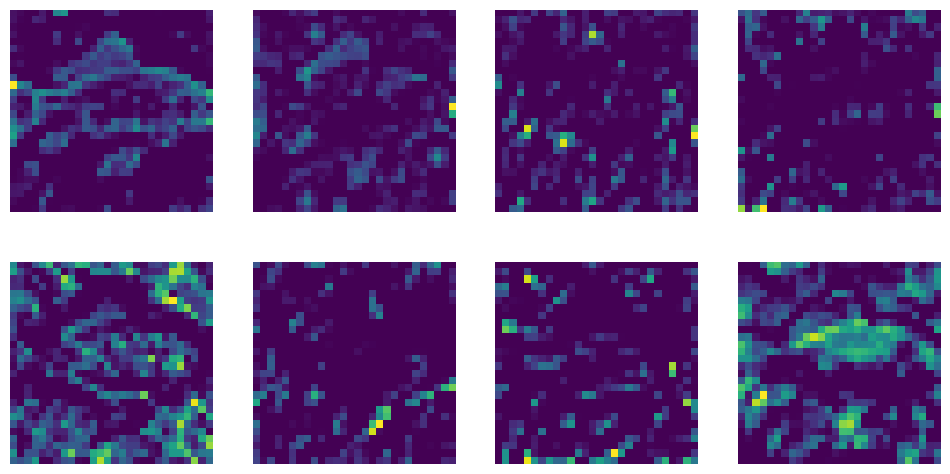

In [83]:
visualize_feature_maps(model, model.layer2[-1], "pictures/gold.jpg")


In this middle layer, the model has passed on feature maps of fewer pixels (just like the last example). That is why we can actually see the pixels. The maps look less like the original image, have stronger contrasts ect.

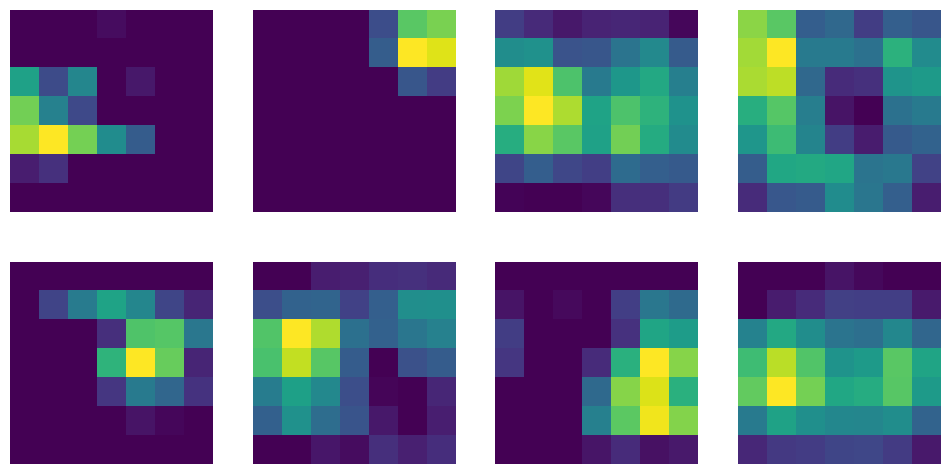

In [84]:
visualize_feature_maps(model, model.layer4[-1], "pictures/gold.jpg")

As before, the late layer output feature maps that have few pixels, and activations that are hard to interpete visually. The layer represents concepts, rather than concrete image structures.

These feature maps together illustrate how the deep CNN-model builds a hierarcical understanding of the image.

### An example of an image containing a class NOT present in the pre-trained model - dragon

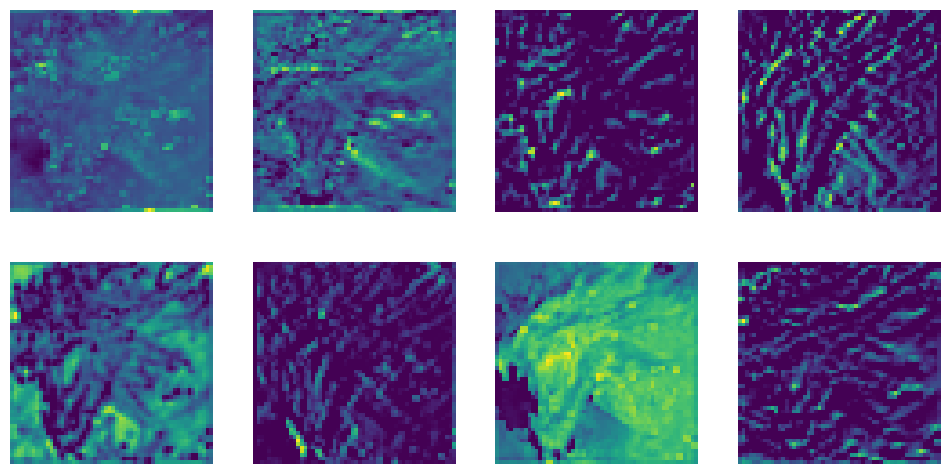

In [85]:
visualize_feature_maps(model, model.layer1[0], "pictures/dragon.jpeg")

Feature maps still get activated and react to visual patterns.  CNN:s extract features from any pictures, even if it is a picture that does not contain a class the model is trained on.

In these feature maps from an early layer, wee se strong constrast where the model finds clear edges.
We also see texture/reptitive patterns that look a bit scales. 

Early layer's feature maps are building blocks for the rest of the network.

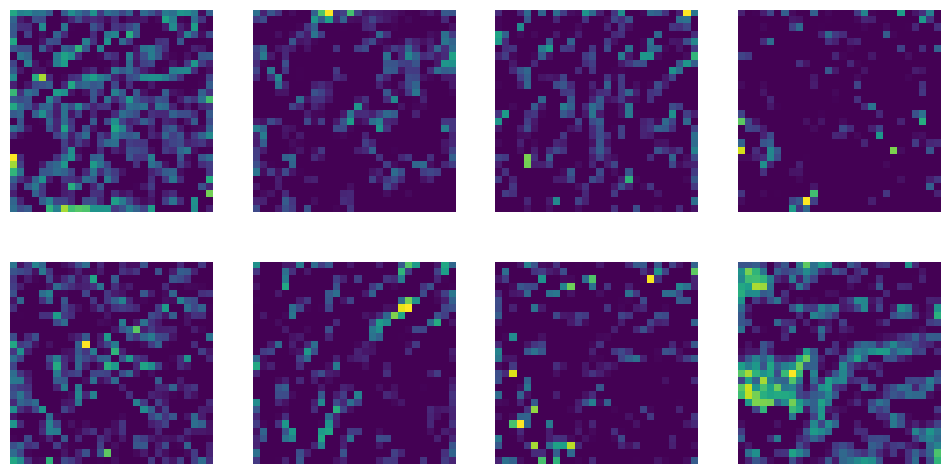

In [86]:
visualize_feature_maps(model, model.layer2[-1], "pictures/dragon.jpeg")

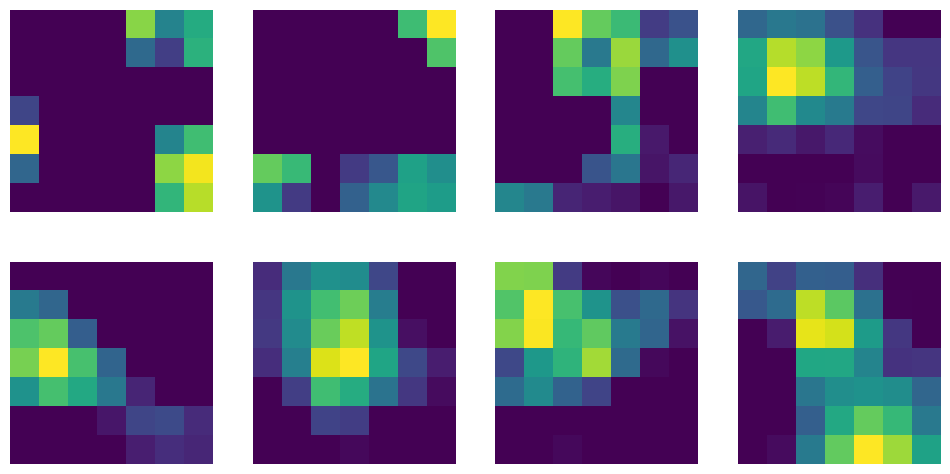

In [87]:
visualize_feature_maps(model, model.layer4[-1], "pictures/dragon.jpeg")

In this late layer, we get very abstract activations. Just like for the positive examples. The model is trying to combine patterns into something that ressembles one of the classes it is trained on.

Extra: Let's make a Class Attribution Map for the dragon image. Picking the class "marmot", the CAM will show which regions of the image contribute most to the model's score for this class. 

As you can see below, the CAM highlights the face, which must bear some ressemblance to marmots.

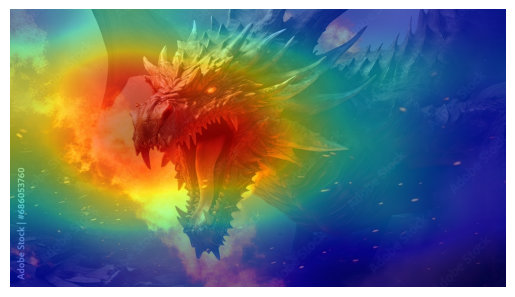

Top 5 classes:
 980  8.7954  volcano
 396  8.7042  lionfish
   7  7.5419  cock
  51  7.4316  triceratops
 115  7.0609  sea slug


In [92]:
generate_cam("pictures/dragon.jpeg", "marmot")

It is fun to see the list of the highest logits - the model thinks the dragon most ressembles a volcano!